<a href="https://colab.research.google.com/github/x3gan/elte-msc/blob/main/Deep%20Network%20Development/Object_Detection_YOLO11_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object Detection**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> Object Detection</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 8px;">
    <span style="font-size: 20px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development</span>
  </div>
  <div style="margin-top: 12px; font-size: 14px;">
    <span style="font-size: 18px; color: #6e8192;">&#128100;</span>
    <span style="font-weight: bold;"><strong>Authors:</strong></span> Tamás Takács, Imre Molnár (PhD students, Department of Artificial Intelligence, Eötvös Loránd University)
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://i.ibb.co/zhJD9C11/object-detection-examples.png" alt="object-detection-examples" border="0">

Object detection is a task that involves **identifying the location and class of objects in an image or video stream**.

The output of an object detector is a set of `bounding boxes` that enclose the objects in the image, along with `class labels` and confidence scores for each box. Object detection is a good choice when you need to identify objects of interest in a scene, but don't need to know exactly where the object is or its exact shape.

# **Models**

YOLO11 pretrained Detect models are shown here. **Detect** models are pretrained on the [**COCO**](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco.yaml) dataset, while Classify models are pretrained on the [**ImageNet**](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/ImageNet.yaml) dataset.

[Models](https://github.com/ultralytics/ultralytics/tree/main/ultralytics/cfg/models) download automatically from the latest Ultralytics [release](https://github.com/ultralytics/assets/releases) on first use.

| Model   | Size (pixels) | mAPval 50-95 | Speed CPU ONNX (ms) | Speed T4 TensorRT10 (ms) | Params (M) | FLOPs (B) |
|---------|---------------|--------------|---------------------|--------------------------|------------|-----------|
| YOLO11n | 640           | 39.5         | 56.1 ± 0.8          | 1.5 ± 0.0                | 2.6        | 6.5       |
| YOLO11s | 640           | 47.0         | 90.0 ± 1.2          | 2.5 ± 0.0                | 9.4        | 21.5      |
| YOLO11m | 640           | 51.5         | 183.2 ± 2.0         | 4.7 ± 0.1                | 20.1       | 68.0      |
| YOLO11l | 640           | 53.4         | 238.6 ± 1.4         | 6.2 ± 0.1                | 25.3       | 86.9      |
| YOLO11x | 640           | 54.7         | 462.8 ± 6.7         | 11.3 ± 0.2               | 56.9       | 194.9     |


- **mAP<sub>val</sub>** values are for single-model single-scale on [COCO val2017](https://cocodataset.org/#home) dataset.
  - Reproduce by: `yolo val detect data=coco-seg.yaml device=0`
- **Speed** averaged over COCO val images using an [Amazon EC2 P4d](https://aws.amazon.com/ec2/instance-types/p4/) instance.
  - Reproduce by: `yolo val detect data=coco-seg.yaml batch=1 device=0|cpu`

### Key Points:
- **Different Models**:
  - The models range from **YOLO11n** (smallest, fastest, least parameters) to **YOLO11x** (largest, slowest, most parameters).
  - As you move from **n** to **x**, model size, accuracy (mAP), and computational requirements increase.
  
- **Why Choosing the Right Model Matters**:
  - **Speed vs. Accuracy**: Smaller models like **YOLO11n** are faster and require fewer computational resources but have lower accuracy. On the other hand, **YOLO11x** provides higher accuracy but is slower and more computationally expensive.
  - **Use Case Considerations**: Depending on your application (e.g., real-time scenarios, resource-limited devices, or cases needing high accuracy), you should choose a model that balances speed, accuracy, and hardware requirements.

In [ ]:
# @title Roadmap Generator
%%capture flowchart_output
from graphviz import Digraph

def create_yolo11_detection_flowchart(output_filename='yolo11_detection_flowchart'):
    dot = Digraph(name='YOLO11_Object_Detection', format='png')
    dot.attr(rankdir='LR')
    dot.attr('node', shape='box', style='filled', fontsize='12', fontname='Arial')

    # Installation & Setup
    dot.node('Install', 'Install Ultralytics Package\n(Easy)', fillcolor='#A0E7A0')

    # Data Acquisition & Model Downloads
    dot.node('Data', 'Download Data & Pretrained Models\n(Easy)', fillcolor='#A0E7A0')

    # Training Phase (CLI)
    dot.node('Train', 'Train YOLO11 Detector\n(Using CLI)\n(Easy)', fillcolor='#A0E7A0')

    # Validation Phase (CLI)
    dot.node('Validate', 'Validate YOLO11 Model\n(Easy)', fillcolor='#A0E7A0')

    # Inference via CLI
    dot.node('Infer_CLI', 'Run Inference via CLI\n(Easy)', fillcolor='#A0E7A0')

    # Inference via Python API
    dot.node('Infer_Python', 'Run Inference via Python API\n(Moderate)', fillcolor='#F6D49A')

    # Output Display & Analysis
    dot.node('Display', 'Display & Analyze Outputs\n(Moderate)', fillcolor='#F6D49A')

    # Define the pipeline flow
    dot.edge('Install', 'Data')
    dot.edge('Data', 'Train')
    dot.edge('Data', 'Validate')
    dot.edge('Train', 'Infer_CLI')
    dot.edge('Validate', 'Infer_CLI')
    dot.edge('Infer_CLI', 'Infer_Python')
    dot.edge('Infer_Python', 'Display')

    dot.render(output_filename, view=False)

create_yolo11_detection_flowchart('yolo11_detection_flowchart')


# **Installing the Ultralytics Package**

Ultralytics is the organization behind the development of YOLO (You Only Look Once) family of models for object detection, segmentation, and pose estimation, and provides tools and pretrained models for computer vision tasks.

In [ ]:
!pip install -qq ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.7 MB/s eta 0:00:00


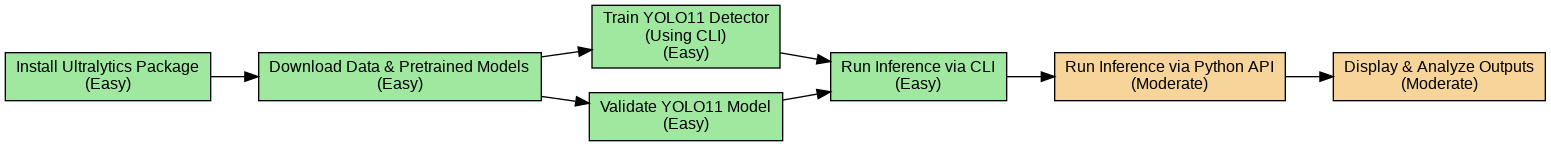

In [ ]:
from IPython.display import Image as IMG
IMG('yolo11_detection_flowchart.png')

**YOLO11** offers two distinct approaches for training, validating, and predicting with a model:

- **Command-Line Interface (CLI)**: A straightforward, non-Pythonic method that leverages the Ultralytics package to handle everything seamlessly in the background, without needing any code.
  
- **Pythonic Approach**: A more traditional method that allows for greater flexibility and customization, where you work directly with the Python API to manage the model's functionality programmatically.

# **Train**

You have three options to choose from when training a model:
- **Build a new model from YAML**: Start from scratch by specifying model architecture in a YAML file (includes a download script for the coco8 dataset as well).
- **Load a pretrained model**: Use a pretrained model to fine-tune or continue training, recommended for most use cases.
- **Build from YAML and transfer weights**: Define your model architecture in YAML and load pretrained weights for a head start on training.

Downloading the `yolo11-nano` model with the `coco8-seg` dataset.

In [ ]:
!wget -qq https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt
!wget -qq https://raw.githubusercontent.com/ultralytics/ultralytics/refs/heads/main/ultralytics/cfg/datasets/coco8.yaml

The `coco8-seg.yaml` has the following format:

```bash
# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# COCO8 dataset (first 8 images from COCO train2017) by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/detect/coco8/
# Example usage: yolo train data=coco8.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── coco8  ← downloads here (1 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: ../datasets/coco8 # dataset root dir
train: images/train # train images (relative to 'path') 4 images
val: images/val # val images (relative to 'path') 4 images
test: # test images (optional)

# Classes
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: refrigerator
  73: book
  74: clock
  75: vase
  76: scissors
  77: teddy bear
  78: hair drier
  79: toothbrush

# Download script/URL (optional)
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip

```

## Building a New Model **(CLI)**

The expected `mAP50` for validation is approximately 0.

All training runs, including metrics, plot images, CSV logs, and model weights, are saved in the directory: `/content/runs/detect/train`

In [ ]:
!yolo detect train data=coco8.yaml model=yolo11n.yaml epochs=100 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=Fal

## Loading a Pretrained Model **(CLI)**

The expected `mAP50` (class average precision) for validation is approximately 0.941. The mask average precision should be around `0.849`

All training runs, including metrics, plot images, CSV logs, and model weights, are saved in the directory: `/content/runs/detect/train2`

In [ ]:
!yolo detect train data=coco8.yaml model=yolo11n.pt epochs=100 imgsz=640

Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_wi

# Validation

You have two options to choose from when validating a model:
- **Validate an official model**: `yolo11n.pt`, `yolo11x.pt` etc.
- **Validate your trained model**: `best.pt`

## Validate an Official Model **(CLI)**

The expected `mAP50` (class average precision) for validation is approximately 0.917. Pose `mAP50` is approximately 0.772.

All training runs, including metrics, plot images, CSV logs, and model weights, are saved in the directory: `/content/runs/detect/val`

In [ ]:
!yolo detect val model=yolo11n.pt

WARNING ⚠️ 'data' argument is missing. Using default 'data=coco8.yaml'.
Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  3.30it/s]
                   all          4         17       0.57       0.85      0.847      0.632
                person          3         10      0.557        0.6      0.585      0.272
                   dog          1          1      0.548          1      0.995      0.697
                 horse          1          2      0.531          1      0.995      0.674
              elephant          1          2      0.371        0.5      0.516      0.256
              umbrella          1          1      0.569          1      0.

# Inference

You have two options to choose from when testing a model:
- **Test an official model**: `yolo11n.pt`, `yolo11x.pt` etc.
- **Test your trained model**: `best.pt`

## Infer an Official Model **(CLI)**

The output of YOLO’s prediction, which includes an image with detected people and their corresponding keypoints, is saved in the `/content/runs/detect/predict` folder.

In [ ]:
!yolo detect predict model=yolo11n.pt source='https://ultralytics.com/images/bus.jpg'

Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 134k/134k [00:00<00:00, 7.98MB/s]
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 49.0ms
Speed: 8.6ms preprocess, 49.0ms inference, 134.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


## Displaying the output

It's important to note that **YOLO** first performs object detection as a prerequisite for segmentation. This means the model must identify objects in the image before it can accurately generate and display their segmentation masks.

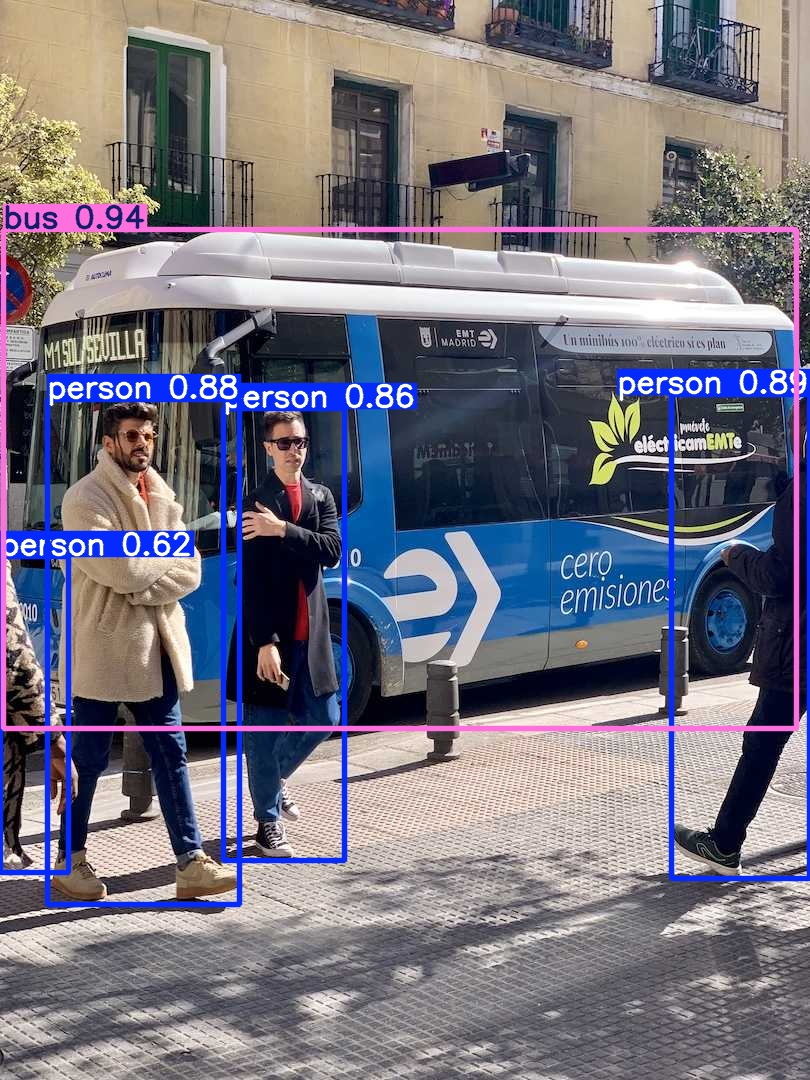

In [ ]:
from IPython.display import Image
Image('/content/runs/detect/predict/bus.jpg')

## Infer an Official Model **(Python)**

Now, let's perform inference using a larger, more advanced model, `yolo11x`, for improved results.

This step involves importing the necessary libraries and downloading the `yolo11x` model.

In [ ]:
!wget -qq https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11x.pt

from PIL import Image
import ultralytics
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import numpy as np
import random
import cv2

In [ ]:
!wget https://i.ibb.co/Qr6c3CX/08eat-square640-v2.jpg
!wget https://i.ibb.co/VVnQPs1/34510-2.jpg

--2025-02-04 13:00:55--  https://i.ibb.co/Qr6c3CX/08eat-square640-v2.jpg
Resolving i.ibb.co (i.ibb.co)... 108.181.22.211
Connecting to i.ibb.co (i.ibb.co)|108.181.22.211|:443... failed: Connection timed out.
Retrying.

--2025-02-04 13:03:06--  (try: 2)  https://i.ibb.co/Qr6c3CX/08eat-square640-v2.jpg
Connecting to i.ibb.co (i.ibb.co)|108.181.22.211|:443... ^C
--2025-02-04 13:03:12--  https://i.ibb.co/VVnQPs1/34510-2.jpg
Resolving i.ibb.co (i.ibb.co)... 108.181.22.211
Connecting to i.ibb.co (i.ibb.co)|108.181.22.211|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51957 (51K) [image/jpeg]
Saving to: ‘34510-2.jpg’

34510-2.jpg         100%[===================>]  50.74K  --.-KB/s    in 0.01s   

2025-02-04 13:03:12 (3.90 MB/s) - ‘34510-2.jpg’ saved [51957/51957]



In [ ]:
ultralytics.checks()
print(f"Setup complete. Using torch {torch.__version__} on device ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

# load an official model
model = ultralytics.YOLO("yolo11n.pt")
# predict on multiple images
results = model(["/content/08eat-square640-v2.jpg", "/content/34510-2.jpg"], conf=0.25)

Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.1/235.7 GB disk)
Setup complete. Using torch 2.5.1+cu124 on device (Tesla T4)

0: 640x640 2 cups, 3 knifes, 3 bowls, 1 cake, 1 dining table, 9.7ms
1: 640x640 1 potted plant, 1 vase, 9.7ms
Speed: 4.0ms preprocess, 9.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


Visualizing the model architecture

In [ ]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): ModuleList(
          (0): Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): Conv(
              (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
    

Going trough the output for all images and displaying them.

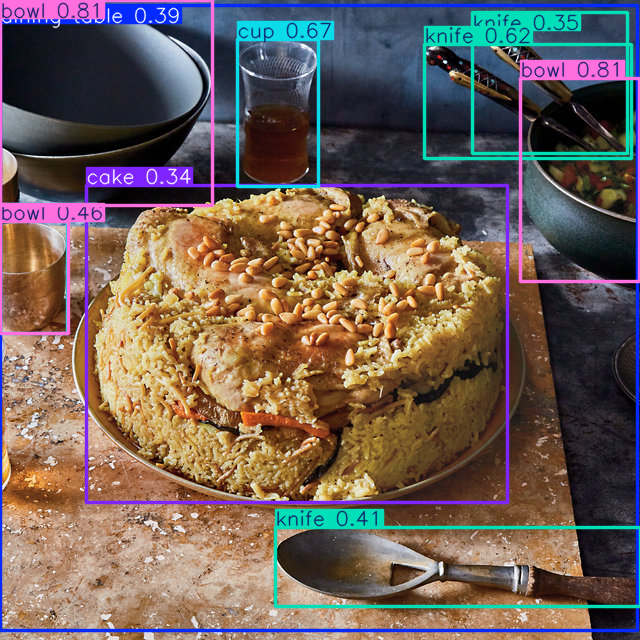

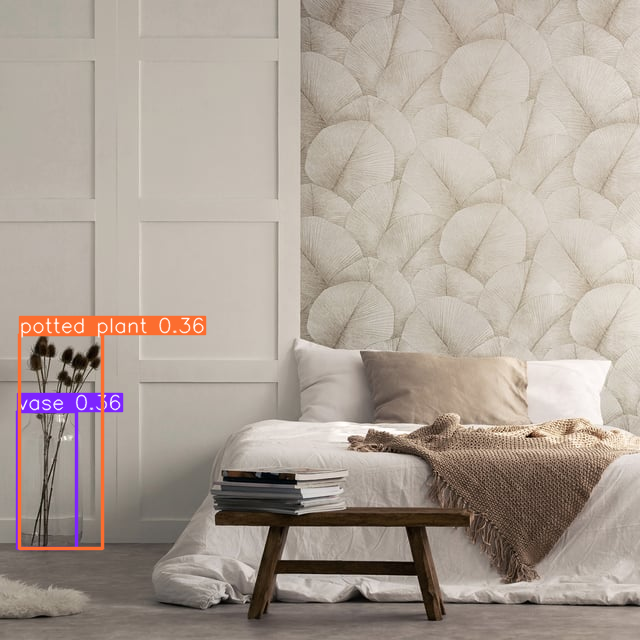

In [ ]:
for i, result in enumerate(results):
    result.show()  # display to screen
    result.save(filename=f"/content/runs/detect/result_{i}.jpg")  # save to disk

In [ ]:
for i, result in enumerate(results):
    boxes = result.boxes  # Boxes object for bounding box outputs
    print(f'Bounding boxes shape: {boxes.shape} - The first dimension represents the number of objects in the image, with each box consisting of 6 values: x_center, y_center, width, height, confidence, class.')

Bounding boxes shape: torch.Size([10, 6]) - The first dimension represents the number of objects in the image, with each box consisting of 6 values: x_center, y_center, width, height, confidence, class.
Bounding boxes shape: torch.Size([2, 6]) - The first dimension represents the number of objects in the image, with each box consisting of 6 values: x_center, y_center, width, height, confidence, class.


The `xy` tensor stores the pixel coordinates for all the locations containing an object.

Class labels are not stored in `result.boxes`. **YOLO** first detects objects within an image using bounding boxes and classifies them into specific categories (classes) during object detection.

Additionally, the `xyn` tensor contains the normalized `x` and `y` values for each masked pixel, ensuring that the positions are scaled appropriately.

In [ ]:
print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([58., 75.], device='cuda:0')
conf: tensor([0.3638, 0.3581], device='cuda:0')
data: tensor([[1.9280e+01, 3.3410e+02, 1.0272e+02, 5.4859e+02, 3.6383e-01, 5.8000e+01],
        [1.7718e+01, 4.1124e+02, 7.6252e+01, 5.4886e+02, 3.5815e-01, 7.5000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[ 60.9997, 441.3423,  83.4398, 214.4943],
        [ 46.9847, 480.0526,  58.5336, 137.6237]], device='cuda:0')
xywhn: tensor([[0.0953, 0.6896, 0.1304, 0.3351],
        [0.0734, 0.7501, 0.0915, 0.2150]], device='cuda:0')
xyxy: tensor([[ 19.2798, 334.0952, 102.7196, 548.5894],
        [ 17.7179, 411.2408,  76.2516, 548.8645]], device='cuda:0')
xyxyn: tensor([[0.0301, 0.5220, 0.1605, 0.8572],
        [0.0277, 0.6426, 0.1191, 0.8576]], device='cuda:0')


# **Train Results**

Each training run stores its own set of results, including detailed metrics for both training and validation. These results record losses for bounding box regression (`box loss`), classification (`cls loss`), and distribution focal loss (`dfl loss`), along with precision and recall values. Additionally, the runs report performance metrics such as `mAP` at an `IoU` threshold of 0.50 (`mAP50`) and the average mAP across IoU thresholds ranging from 0.50 to 0.95 (`mAP50-95`). This comprehensive set of metrics provides a clear picture of the model's detection accuracy and helps in evaluating its performance across different aspects of object detection.

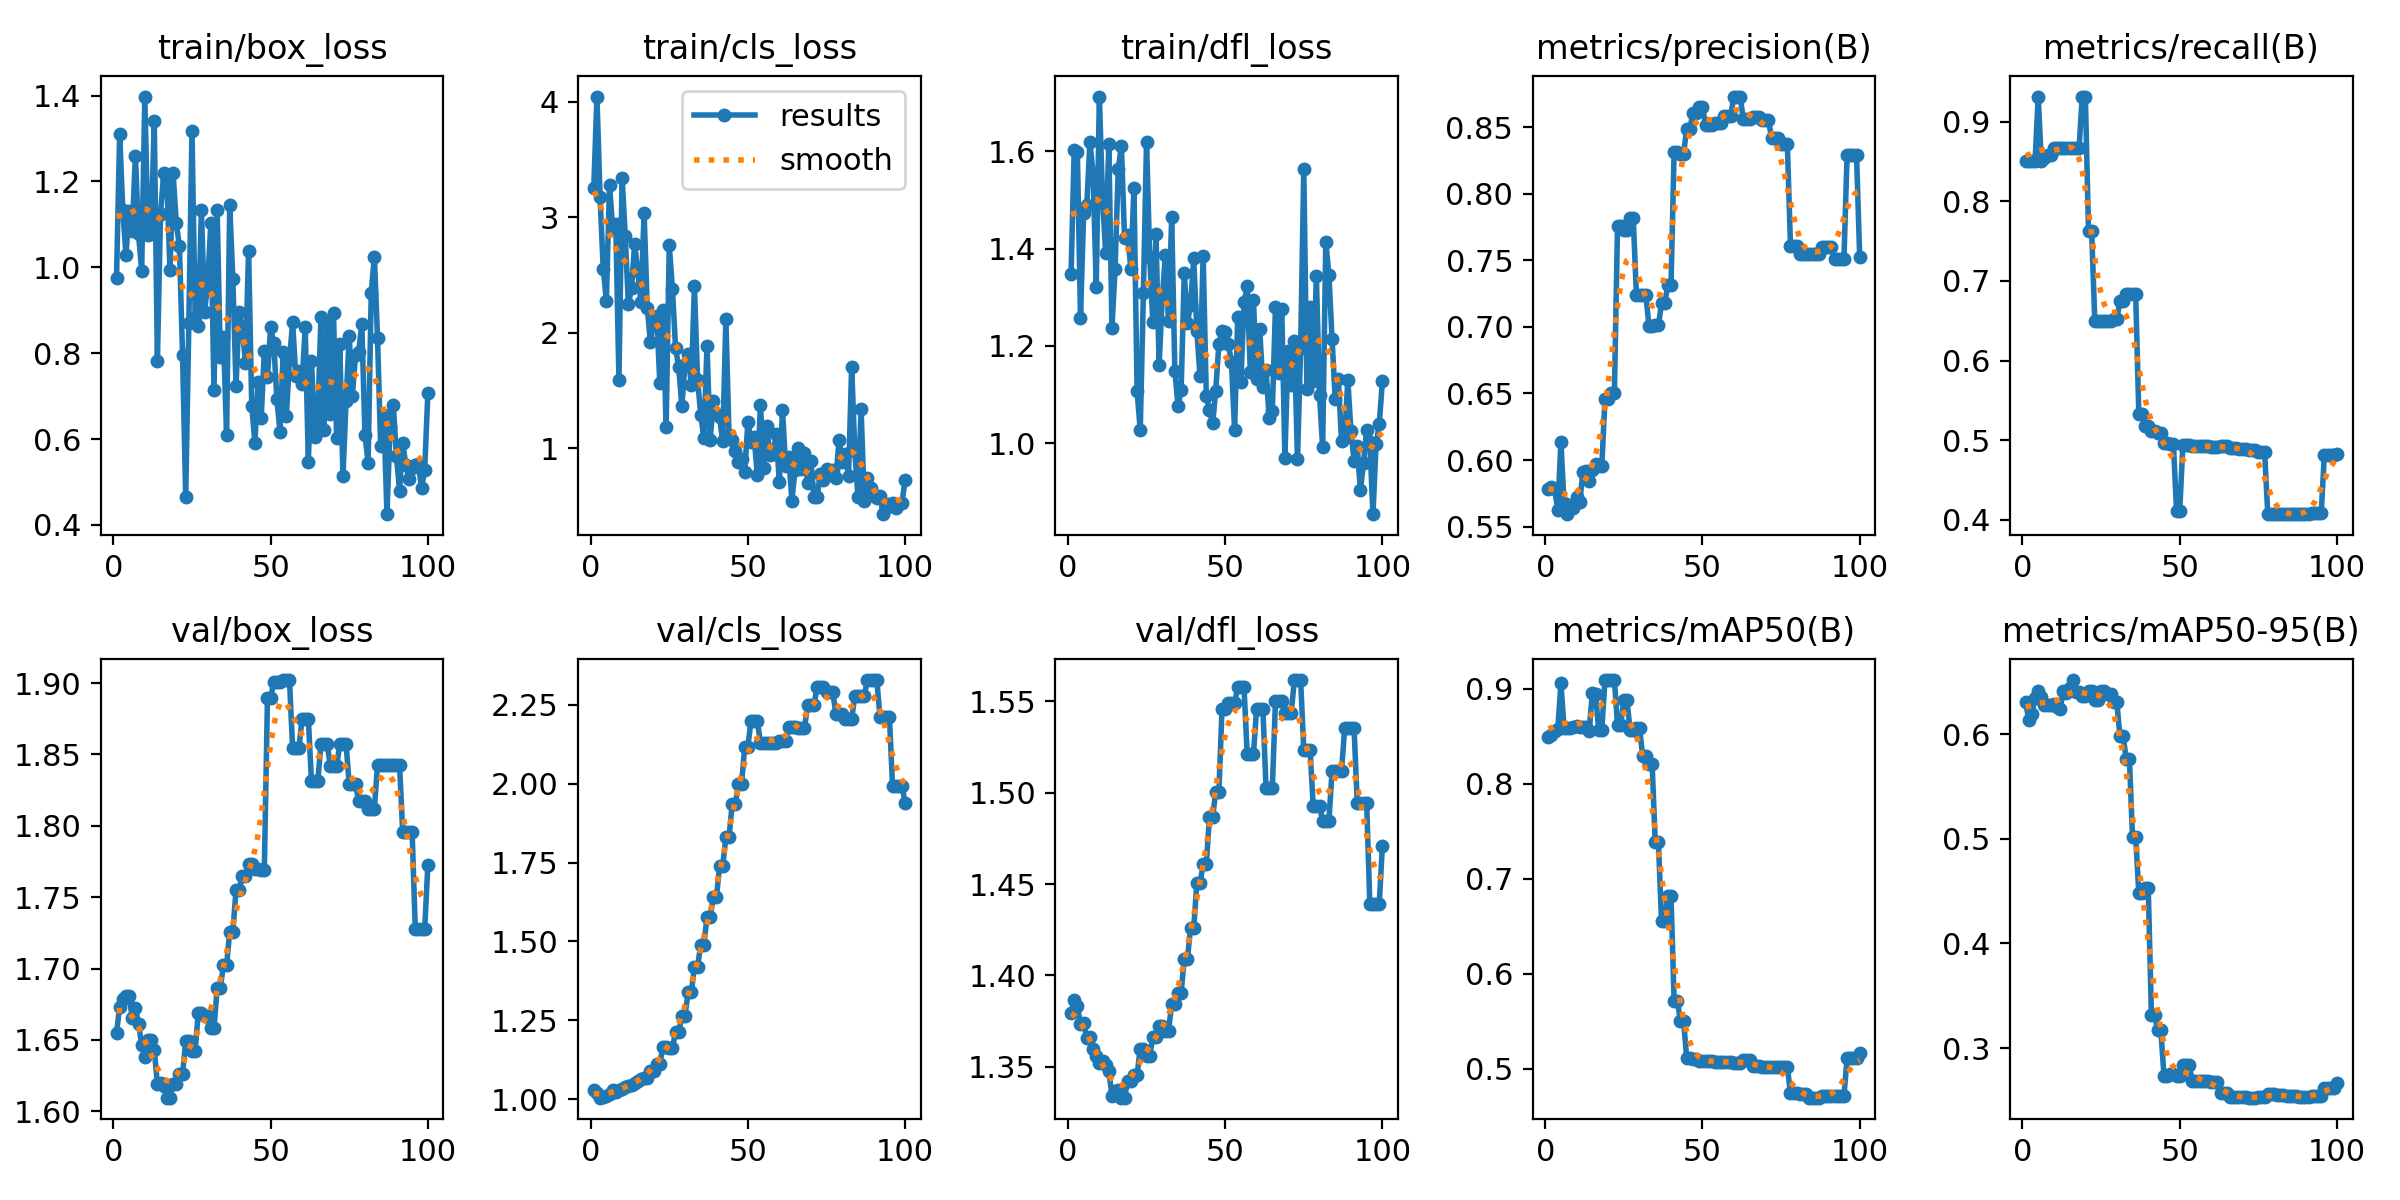

In [ ]:
Image.open('/content/runs/detect/train2/results.png')

### **HOMEWORK (Optional)**

- **Exercise 1: Model Architecture Comparison**  
  Compare the performance (mAP, inference speed, and model size) of different YOLO variants (e.g., YOLO11n, YOLO11s, YOLO11x) on the same object detection task. Analyze the trade-offs between speed and accuracy across these models.

- **Exercise 2: Data Augmentation Impact**  
  Experiment with varying data augmentation techniques during training (e.g., different rotations, scaling factors, and perspective transformations). Evaluate how changes in augmentation affect detection accuracy and robustness on both validation and test sets.

- **Exercise 3: Custom Dataset Fine-Tuning**  
  Fine-tune a pretrained YOLO model on a small custom dataset (for example, a collection of images with a new object class). Assess how transfer learning adapts to the new domain and compare the model’s performance with that on the original dataset.

- **Exercise 4: Real-Time Object Detection Application**  
  Develop a real-time object detection application that processes video frames from a webcam or video file. Implement a system that displays bounding boxes, class labels, and confidence scores on the detected objects in each frame.